# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [18]:
#Seu código de importação aqui
df = pd.read_csv("CHURN_TELECON_PREPROCESSADA.csv", delimiter=',')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,1
3,0895-LMRSF,Male,0,No,No,23,Desconhecido,DSL,No,No,Yes,One year,Bank transfer (automatic),64.90,1509.80,0
4,8098-LLAZX,Female,1,No,No,4,Desconhecido,Fiber optic,No,No,Yes,Month-to-month,Electronic check,95.45,396.10,1
5,8266-VBFQL,Male,0,No,No,4,Desconhecido,Fiber optic,No,Yes,No,Month-to-month,Electronic check,90.40,356.65,0
6,8181-YHCMF,Female,0,Yes,Yes,68,Desconhecido,DSL,No,Yes,Yes,Two year,Credit card (automatic),60.30,4109.00,0
7,2240-HSJQD,Male,0,No,Yes,38,Desconhecido,Fiber optic,No,No,No,Month-to-month,Mailed check,81.85,3141.70,0
8,1248-DYXUB,Male,0,Yes,Yes,52,Desconhecido,No,No internet service,No internet service,No internet service,Two year,Mailed check,24.80,1229.10,0
9,0265-EDXBD,Male,1,Yes,No,32,Desconhecido,Fiber optic,No,No,No,Month-to-month,Electronic check,74.90,2303.35,1


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [19]:
#Seu código aqui
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago,Churn
count,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000
mean,0.160920,32.441379,65.607563,2298.104115,0.262069
std,0.367541,24.609875,29.931520,2268.309079,0.439861
min,0.000000,0.000000,18.400000,18.800000,0.000000
25%,0.000000,8.500000,39.500000,404.825000,0.000000
50%,0.000000,29.000000,71.450000,1410.250000,0.000000
75%,0.000000,56.000000,90.250000,3894.875000,1.000000
max,1.000000,72.000000,118.650000,8564.750000,1.000000


A) Observa-se que há poucos clientes idosos, já que a média dessa variável é de 0,16, indicando baixa representatividade desse grupo no conjunto de dados. Em relação ao tempo como cliente, a média (32,44) está próxima da mediana (29,0), o que sugere uma distribuição relativamente equilibrada, sem grandes assimetrias. Por fim, na variável de total pago, há indícios de valores discrepantes (outliers). Isso fica evidente pela diferença entre o valor máximo (8564,75) e o terceiro quartil (3894,87), sendo o máximo mais que o dobro do valor que concentra 75% dos dados.

B) Sim, as colunas Total_Pago e Pagamento_Mensal.

C) Ao analisar o boxplot da variável Pagamento_Mensal, observa-se que os dados estão bem distribuídos, sem presença evidente de outliers. Já na variável Total_Pago, existem valores mais altos que se afastam bastante do restante dos dados, indicando possíveis outliers. Em relação à variável Tipo_Contrato, a maioria dos clientes possui contrato mensal (mês a mês), representando mais da metade da base. Isso indica a importância de cruzar essa informação com o tempo de permanência do cliente para entender melhor seu comportamento. A variável Tempo_como_Cliente apresenta uma boa distribuição, com valores que chegam até 72 meses e média de aproximadamente 32 meses. Por fim, na variável Servico_Internet, cerca de 70% dos clientes possuem fibra óptica ou DSL. No entanto, apenas cerca de 50% dos clientes utilizam Suporte_Tecnico, o que pode indicar uma oportunidade de melhoria nesse serviço.

D)As variáveis booleanas que estão no dataframe é Idoso e Church. No entanto, as variaveis não estão bem distribuída, pois há uma quantidade bem menor de clientes Idoso em comparação aos demais. E na Variavel church tbm temos aproximadamente 70% dos dados de clienets que não são church. 


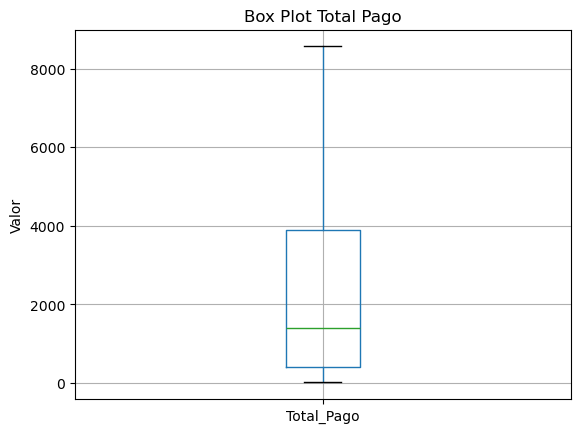

In [34]:
df.boxplot(column='Total_Pago')
plt.title('Box Plot Total Pago')
plt.ylabel('Valor')
plt.show()

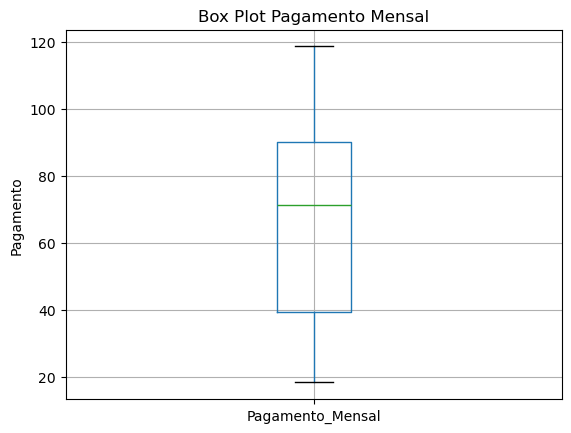

In [38]:
df.boxplot(column='Pagamento_Mensal')
plt.title('Box Plot Pagamento Mensal')
plt.ylabel('Pagamento')
plt.show()

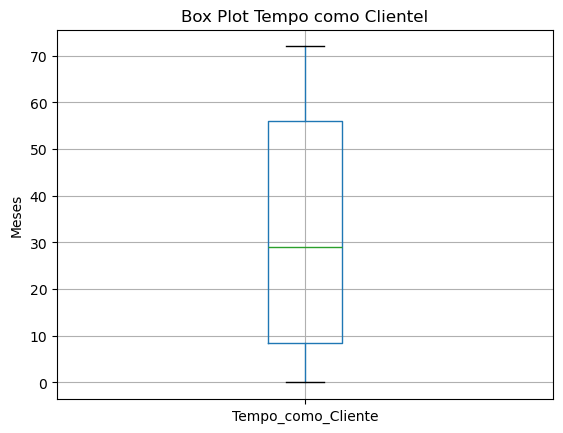

In [16]:
#contagem da coluna 
contagem_tempo_como_cliente = df['Tempo_como_Cliente'].value_counts()

df.boxplot(column='Tempo_como_Cliente')
plt.title('Box Plot Tempo como Clientel')
plt.ylabel('Meses')
plt.show()

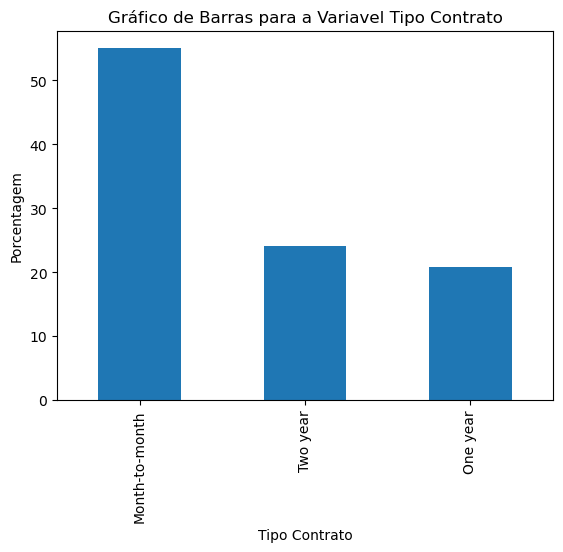

In [12]:
#contagem da coluna Tipo_contrato
contagem_tipo_contrato = df['Tipo_Contrato'].value_counts()

porcentagem_tipo_contrato = (contagem_tipo_contrato/ contagem_tipo_contrato.sum()) * 100
ax = porcentagem_tipo_contrato.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Tipo Contrato')
plt.xlabel('Tipo Contrato')
plt.ylabel('Porcentagem')
plt.show()

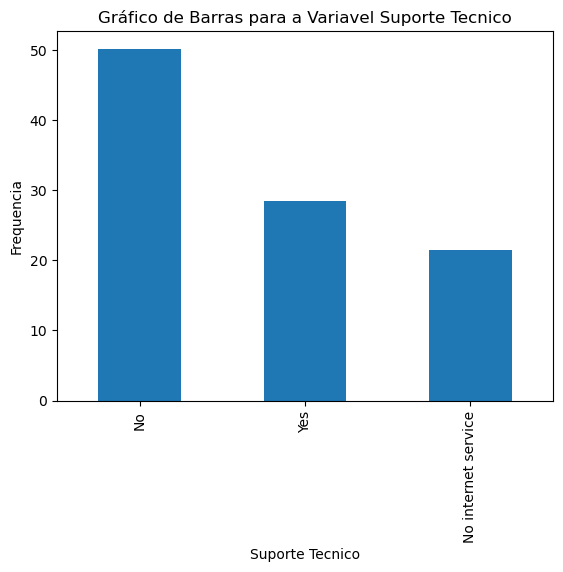

In [11]:
#contagem da coluna genero
contagem_suporte_tecnico = df['Suporte_Tecnico'].value_counts()

porcentagem_suporte_tecnico = (contagem_suporte_tecnico/ contagem_suporte_tecnico.sum()) * 100
ax = porcentagem_suporte_tecnico.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Suporte Tecnico')
plt.xlabel('Suporte Tecnico')
plt.ylabel('Frequencia')
plt.show()

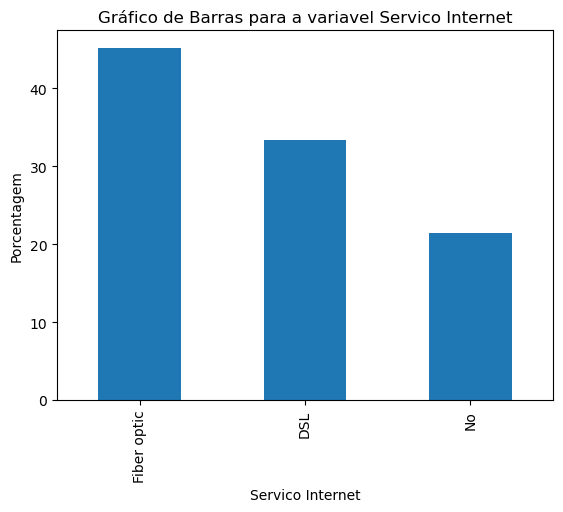

In [42]:
#contagem da coluna servico_internet
contagem_servico_internet = df['Servico_Internet'].value_counts()

porcentagem_servico_internet = (contagem_servico_internet/ contagem_servico_internet.sum()) * 100
ax = porcentagem_servico_internet.plot(kind='bar')
plt.title('Gráfico de Barras para a variavel Servico Internet')
plt.xlabel('Servico Internet')
plt.ylabel('Porcentagem')
plt.show()

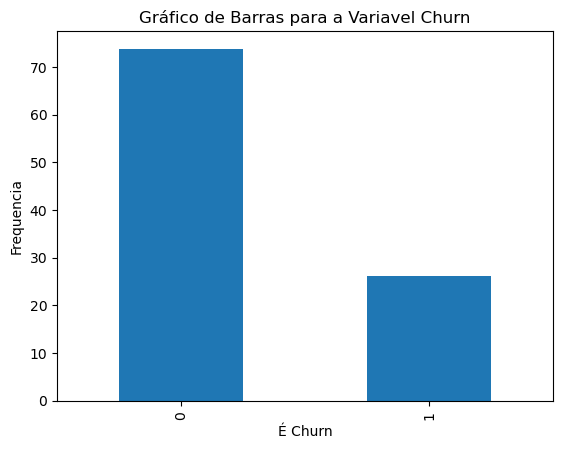

In [40]:
#contagem da coluna churn
contagem_churn = df['Churn'].value_counts()

porcentagem_churn = (contagem_churn/ contagem_churn.sum()) * 100
ax = porcentagem_churn.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Churn')
plt.xlabel('É Churn')
plt.ylabel('Frequencia')
plt.show()

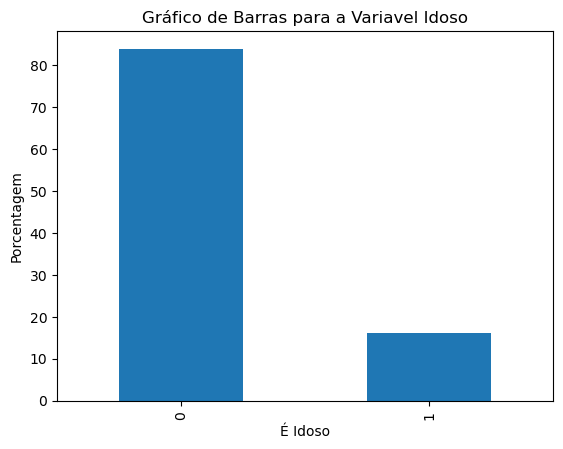

In [37]:
#contagem da coluna idoso
contagem_idoso = df['Idoso'].value_counts()

porcentagem_idoso = (contagem_idoso/ contagem_idoso.sum()) * 100
ax = porcentagem_idoso.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Idoso')
plt.xlabel('É Idoso')
plt.ylabel('Porcentagem')
plt.show()

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


Como os valores da variavel Valor_Total_Pago estão acima de 3500 são valores que não bate com o tempo de cliente, e nem com o pagamento mensal. O total dos dados que são outliers é aproximadamente 25%, o valor fica muito alto para ser deletado. Para fazermos a substituição pelo valor da Média fica muito alto devido a presença dos outliers entao o ideal nesse caso para o número ficar mais equilibrado é fazer a substituição dos valores de outilier pelo valor da mediana.

In [28]:
#Seu código aqui
print ("Porcentagem de registros onde 'Total_Pago' > 3895: ",
       (len(df[df['Total_Pago'] > 3895])/len(df))*100)

Porcentagem de registros onde 'Total_Pago' > 3895:  25.01149425287356


In [25]:
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago,Churn
count,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000
mean,0.160920,32.441379,65.607563,2298.104115,0.262069
std,0.367541,24.609875,29.931520,2268.309079,0.439861
min,0.000000,0.000000,18.400000,18.800000,0.000000
25%,0.000000,8.500000,39.500000,404.825000,0.000000
50%,0.000000,29.000000,71.450000,1410.250000,0.000000
75%,0.000000,56.000000,90.250000,3894.875000,1.000000
max,1.000000,72.000000,118.650000,8564.750000,1.000000


In [33]:
df.loc[df['Total_Pago']>3900, 'Total_Pago'] = df['Total_Pago'].median()

In [36]:
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago,Churn
count,2175.000000,2175.000000,2175.000000,2175.000000,2175.000000
mean,0.160920,32.441379,65.607563,1215.784920,0.262069
std,0.367541,24.609875,29.931520,921.952691,0.439861
min,0.000000,0.000000,18.400000,18.800000,0.000000
25%,0.000000,8.500000,39.500000,404.825000,0.000000
50%,0.000000,29.000000,71.450000,1410.250000,0.000000
75%,0.000000,56.000000,90.250000,1413.425000,1.000000
max,1.000000,72.000000,118.650000,3899.050000,1.000000


# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

A)
Clientes com contrato mês a mês apresentam maior índice de cancelamento.
Clientes com menos tempo de permanência tendem a cancelar mais.
Quem paga valores mais altos também costuma cancelar mais, possivelmente pelo custo-benefício — seria interessante avaliar a satisfação desses clientes.
Clientes sem suporte técnico têm uma taxa maior de cancelamento.
Quem utiliza internet fibra óptica apresenta mais churn em comparação aos demais, o que pode indicar problemas de custo ou qualidade.
Clientes com pagamento automático têm menor índice de cancelamento.

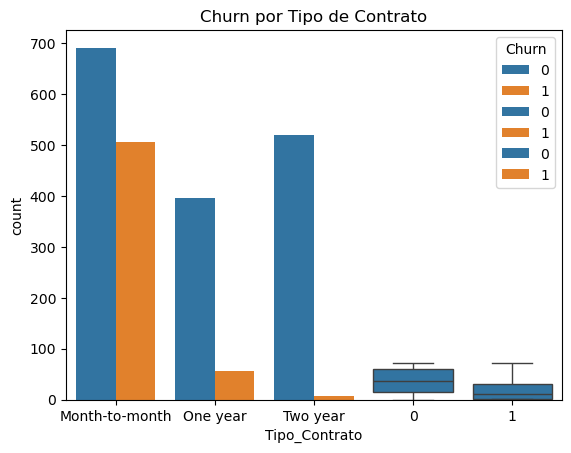

In [40]:
#Seu código aqui
sns.countplot(x='Tipo_Contrato', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.show()

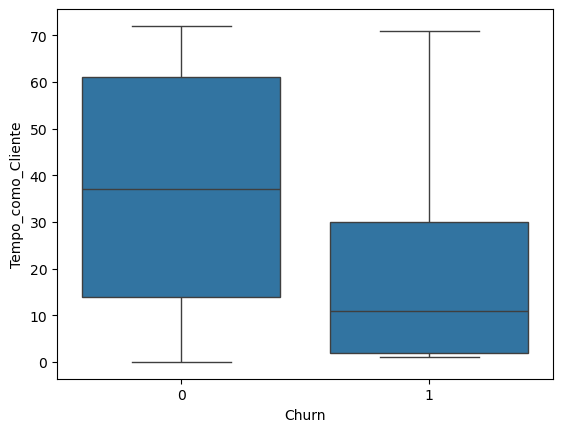

In [41]:
sns.boxplot(x='Churn', y='Tempo_como_Cliente', data=df)
plt.title('Churn por Tempo como Cliente')
plt.show()

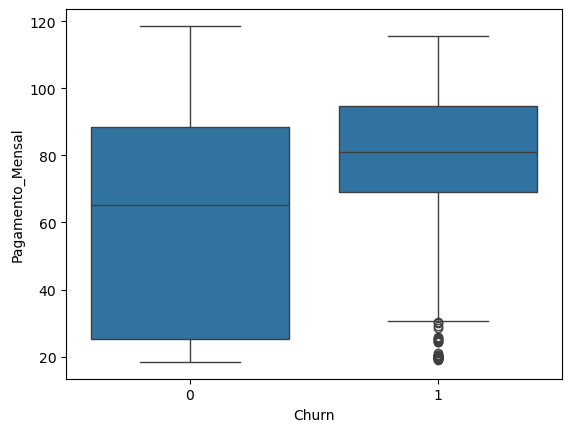

In [42]:
sns.boxplot(x='Churn', y='Pagamento_Mensal', data=df)
plt.title('Churn por Pagamento Mensal')
plt.show()

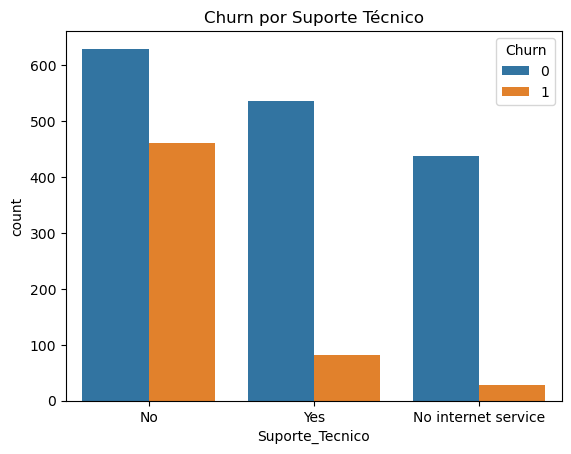

In [45]:
sns.countplot(x='Suporte_Tecnico', hue='Churn', data=df)
plt.title('Churn por Suporte Técnico')
plt.show()


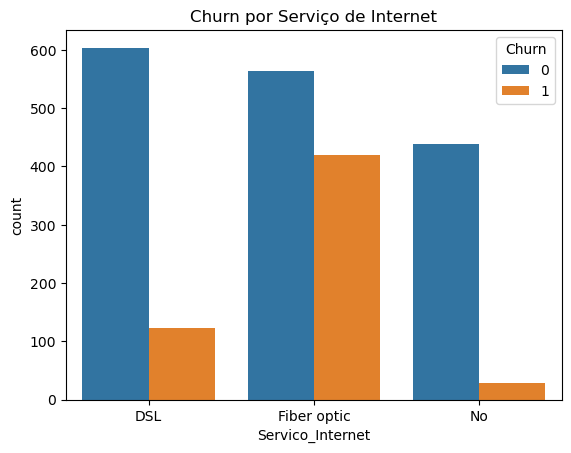

In [46]:
sns.countplot(x='Servico_Internet', hue='Churn', data=df)
plt.title('Churn por Serviço de Internet')
plt.show()

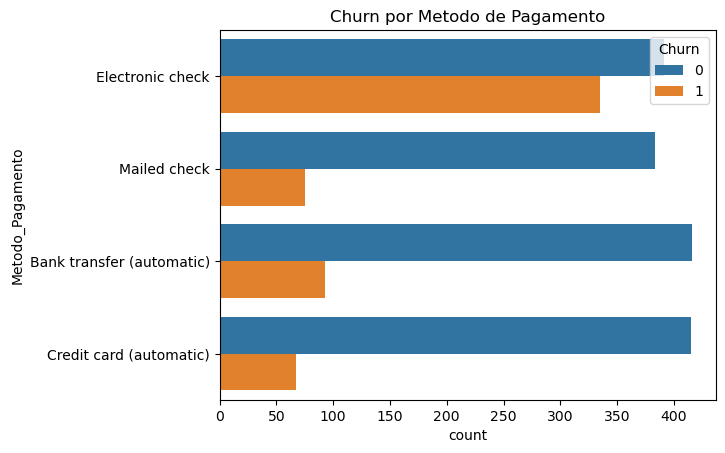

In [47]:
sns.countplot(y='Metodo_Pagamento', hue='Churn', data=df)
plt.title('Churn por Metodo de Pagamento')
plt.show()

B) As variáveis que apresentaram maior relação com o churn foram Tipo_de_Contrato, Tempo_como_Cliente, Pagamento_Mensal e Suporte_Tecnico, indicando que fatores como fidelização, custo e qualidade do serviço influenciam diretamente na decisão de cancelamento dos clientes.